<a href="https://colab.research.google.com/github/PlantScienceDroneMethods/PlantScienceDroneMethods.github.io/blob/main/ObjectDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Image Object Detection Tutorial
This tutorial demonstrates a object detection pipeline for UAV plant breeding images. It loads `.tif` images from a shared drive, processes them using OpenCV and scikit-learn, and prepares annotations including object features like color and shape.

The tutorial is structured into sections: setup, helper functions, parameters, and image processing.

## 📦 Setup: Import Required Libraries

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import math
import keras
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from sklearn.cluster import KMeans
from itertools import compress
from scipy.stats import mode
from scipy.spatial import cKDTree, distance_matrix
from scipy.spatial.distance import cdist

from google.colab import drive

In [ ]:
image = copy.deepcopy(segmentation)



array([[9.9999774e-01, 2.2417421e-06]], dtype=float32)

## 💾 Mount Google Drive

In [ ]:
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


## 🧰 Helper Functions

In [ ]:
def cropSquareFromContour(c, img):

    rect = cv2.minAreaRect(c)
    rect = list(rect)
    rect[1] = (max(rect[1]), max(rect[1]))

    box = cv2.boxPoints(rect)
    box = np.intp(box)
    width = int(max(rect[1]))
    height = int(max(rect[1]))

    src_pts = box.astype("float32")
    dst_pts = np.array([[0, height-1],
                        [0, 0],
                        [width-1, 0],
                        [width-1, height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(img, M, (width, height))

    return warped

classifierModel = keras.layers.TFSMLayer('/content/drive/Shareddrives/UAV tools for plant breeding/pumpkin classifier model/model.savedmodel', call_endpoint = 'serving_default')
classifierClassNames = open('/content/drive/Shareddrives/UAV tools for plant breeding/pumpkin classifier model/labels.txt', "r").read().splitlines()
def classifyImage(cv2Image):
  image = cv2.resize(cv2Image, (224, 224))
  image = Image.fromarray(image)

  # Make the image a numpy array and reshape it to the models input shape.
  image = np.asarray(image, dtype=np.float32).reshape(1, 224, 224, 3)

  # Normalize the image array
  image = (image / 127.5) - 1

  # Predicts the model
  prediction = classifierModel(image)['sequential_3'].numpy()
  return prediction

In [ ]:
img = copy.deepcopy(segmentation)
img = cv2.cvtColor(img, cv2.COLOR_Lab2BGR)
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = Image.fromarray(img)
width_height_tuple = (224, 224)
width, height = img.size
target_width, target_height = width_height_tuple
crop_height = (width * target_height) // target_width
crop_width = (height * target_width) // target_height
crop_height = min(height, crop_height)
crop_width = min(width, crop_width)
crop_box_hstart = (height - crop_height) // 2
crop_box_wstart = (width - crop_width) // 2
crop_box_wend = crop_box_wstart + crop_width
crop_box_hend = crop_box_hstart + crop_height
crop_box = [
    crop_box_wstart, crop_box_hstart, crop_box_wend,
    crop_box_hend
]
img = img.resize(width_height_tuple, Image.NEAREST, box=crop_box)
my_image = np.asarray(img)
my_image = my_image.reshape((1, my_image.shape[0], my_image.shape[1], my_image.shape[2]))
my_image = my_image / 255.
classifierModel(my_image)['sequential_3'].numpy()

array([[4.2783333e-07, 9.9999952e-01]], dtype=float32)

## ⚙️ Parameters and File Paths

In [ ]:
imageDir = '/content/drive/Shareddrives/UAV tools for plant breeding/'
outputDir = '/content/drive/Shareddrives/UAV tools for plant breeding/output/'

downscalingFactor = 1

## 📋 Initialize Annotation Table

In [ ]:
annotations = pd.DataFrame(columns = ['imagePath', 'segmentation', 'size (px)', 'length width ratio', 'L', 'a', 'b', 'R', 'G', 'B'])
# annotations = pd.read_csv(outputDir + 'annotations.csv', index_col=False) # use if you want to add to existing annotations

## 🔁 Process Images and Extract Features

2024-10-28 pumpkins 10m RGB_transparent_mosaic_group1.tif


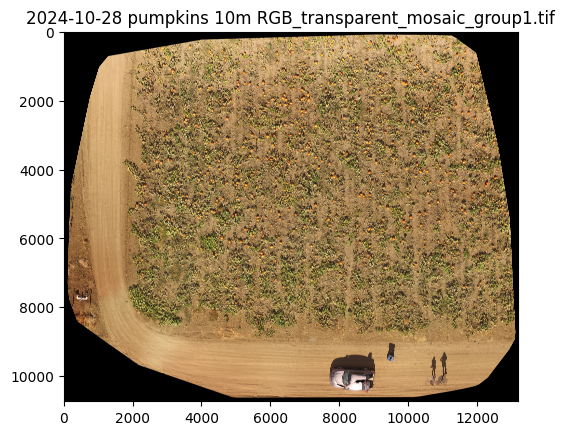

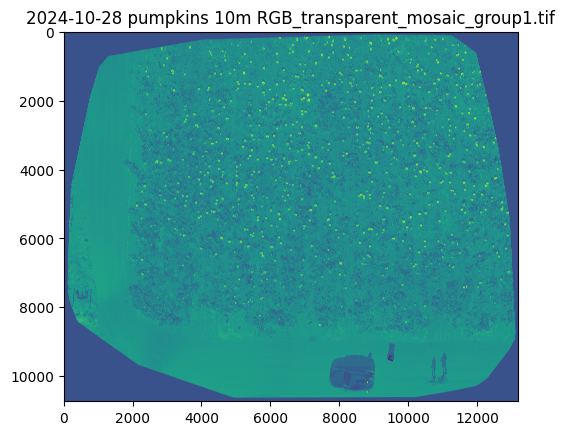

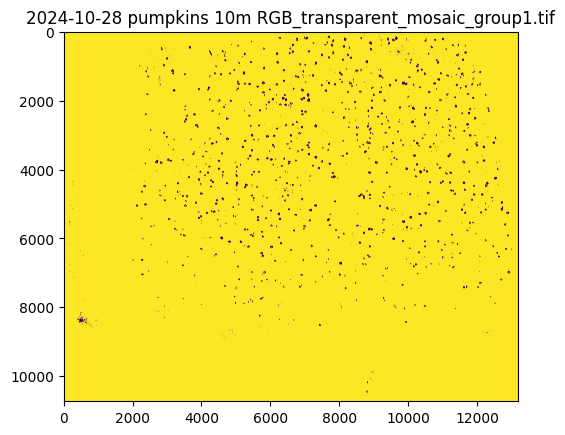

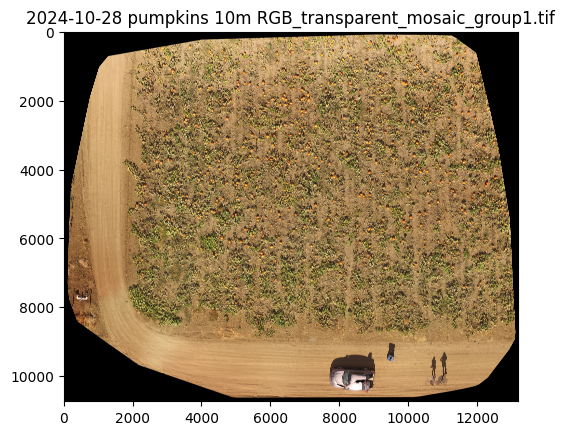

In [ ]:
imagePaths = [i for i in os.listdir(imageDir) if '.tif' in i]

count = 0

for imagePath in imagePaths:
    if(imagePath in annotations['imagePath'].values):
        continue
    print(imagePath)
    image = cv2.imread(imageDir + imagePath)
    image = cv2.copyMakeBorder(image, 100, 100, 100, 100, cv2.BORDER_CONSTANT, value = [0, 0, 0])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    thres = cv2.resize(image, None, fx = 1/downscalingFactor, fy = 1/downscalingFactor)
    plt.figure()
    plt.imshow(cv2.cvtColor(thres, cv2.COLOR_Lab2RGB))
    plt.title(imagePath)
    plt.pause(0.0001)
    distances = cdist(thres[:,:,[1,2]].reshape(thres.shape[0] * thres.shape[1], 2), [[10, 10]])
    thres = distances.reshape(thres.shape[0], thres.shape[1], 1).astype("uint8")
    plt.figure()
    plt.imshow(thres)
    plt.title(imagePath)
    plt.pause(0.0001)
    thres = np.array((thres < 210) * 255).astype("uint8")[:,:,0]
    plt.figure()
    plt.imshow(thres)
    plt.title(imagePath)
    plt.pause(0.0001)
    kernel = np.ones((9, 9), np.uint8)
    thres = cv2.morphologyEx(thres, cv2.MORPH_OPEN, kernel)
    thres = cv2.resize(thres, None, fx = downscalingFactor, fy = downscalingFactor)
    contours, hierarchy = cv2.findContours(thres, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    filteredContours = []
    for i, contour in enumerate(contours):
            rect = cv2.minAreaRect(contour)
            rectArea = rect[1][0] * rect[1][1]
            if(rectArea > 1000 and rectArea < (thres.shape[0] * thres.shape[1] * 0.05)): # 250
                area = cv2.contourArea(contour)
                LWR = np.max(rect[1]) / np.min(rect[1])
                canvas = np.zeros(thres.shape).astype("uint8")
                canvas = cv2.drawContours(canvas, [contour], -1, 255, cv2.FILLED)
                segmentationMask = cropSquareFromContour(contour, canvas)
                segmentation = cropSquareFromContour(contour, image)
                confidence = classifyImage(cv2.cvtColor(segmentation, cv2.COLOR_Lab2RGB))
                thisClass = classifierClassNames[np.argmax(confidence)]
                # plt.figure()
                # plt.imshow(cv2.cvtColor(segmentation, cv2.COLOR_Lab2RGB))
                # plt.title(confidence)
                # plt.pause(0.0001)
                if thisClass == "pumpkin":
                  LabColor = np.array([i for i in segmentation.reshape(-1, 3) if (i != [255, 128, 128]).all()]).mean(axis = 0)
                  RGBColor = np.array([i for i in cv2.cvtColor(segmentation, cv2.COLOR_Lab2RGB).reshape(-1, 3) if (i != [255, 255, 255]).all()]).mean(axis = 0)
                  cv2.imwrite(outputDir + 'segmentations/' + imagePath + '_' + str(len(filteredContours) + 1) + '.jpg', cv2.cvtColor(segmentation, cv2.COLOR_Lab2BGR))
                  if(LabColor.size == 1 or RGBColor.size == 1):
                    continue
                  annotations.loc[len(annotations.index)] = [imagePath, str(len(filteredContours) + 1), area, LWR, LabColor[0], LabColor[1], LabColor[2], RGBColor[0], RGBColor[1], RGBColor[2]]
                  filteredContours.append(contour)

    for filteredContour in filteredContours:
        rect = cv2.minAreaRect(filteredContour)
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        image = cv2.drawContours(image,[box],0,(255,0,0),2)
    plt.figure()
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_Lab2RGB))
    plt.title(imagePath)
    plt.pause(0.0001)

    annotations.to_csv(outputDir + 'annotations.csv', index=False)

## 💾 Save Annotations to File (Optional)

In [ ]:
cv2.imwrite(outputDir + 'annotated.jpg', cv2.cvtColor(image, cv2.COLOR_Lab2BGR))

True